In [1]:
import numpy as np
import matplotlib.pyplot as plt

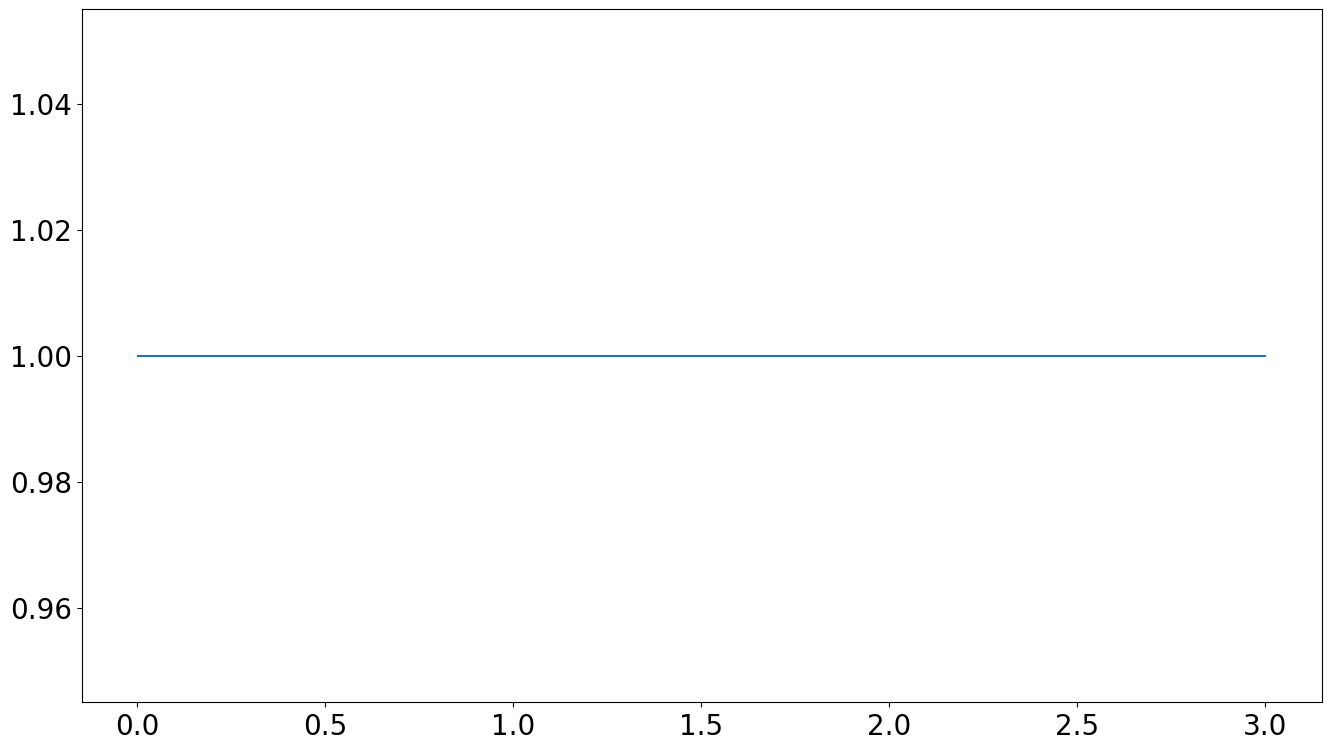

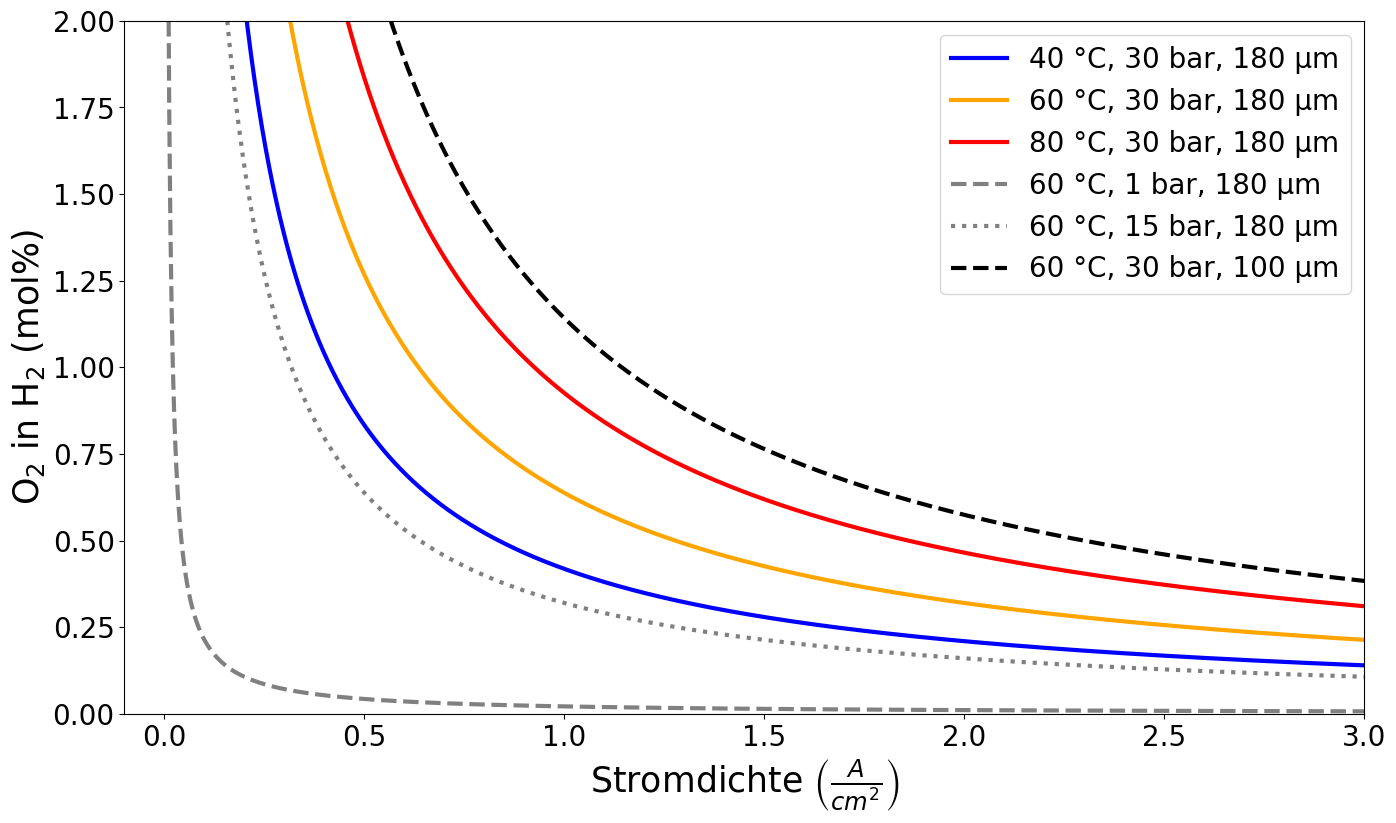

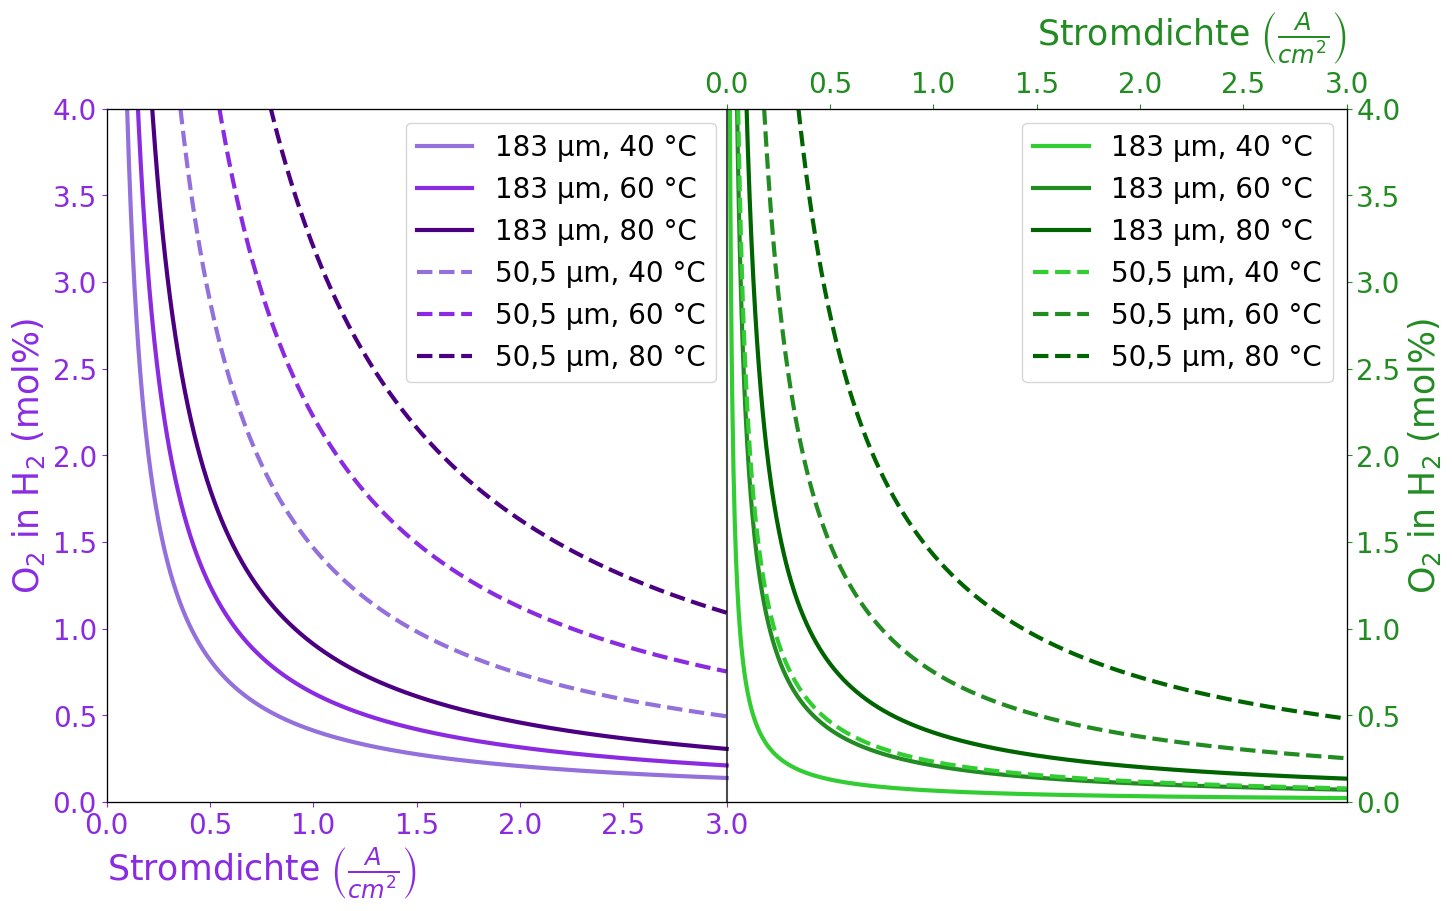

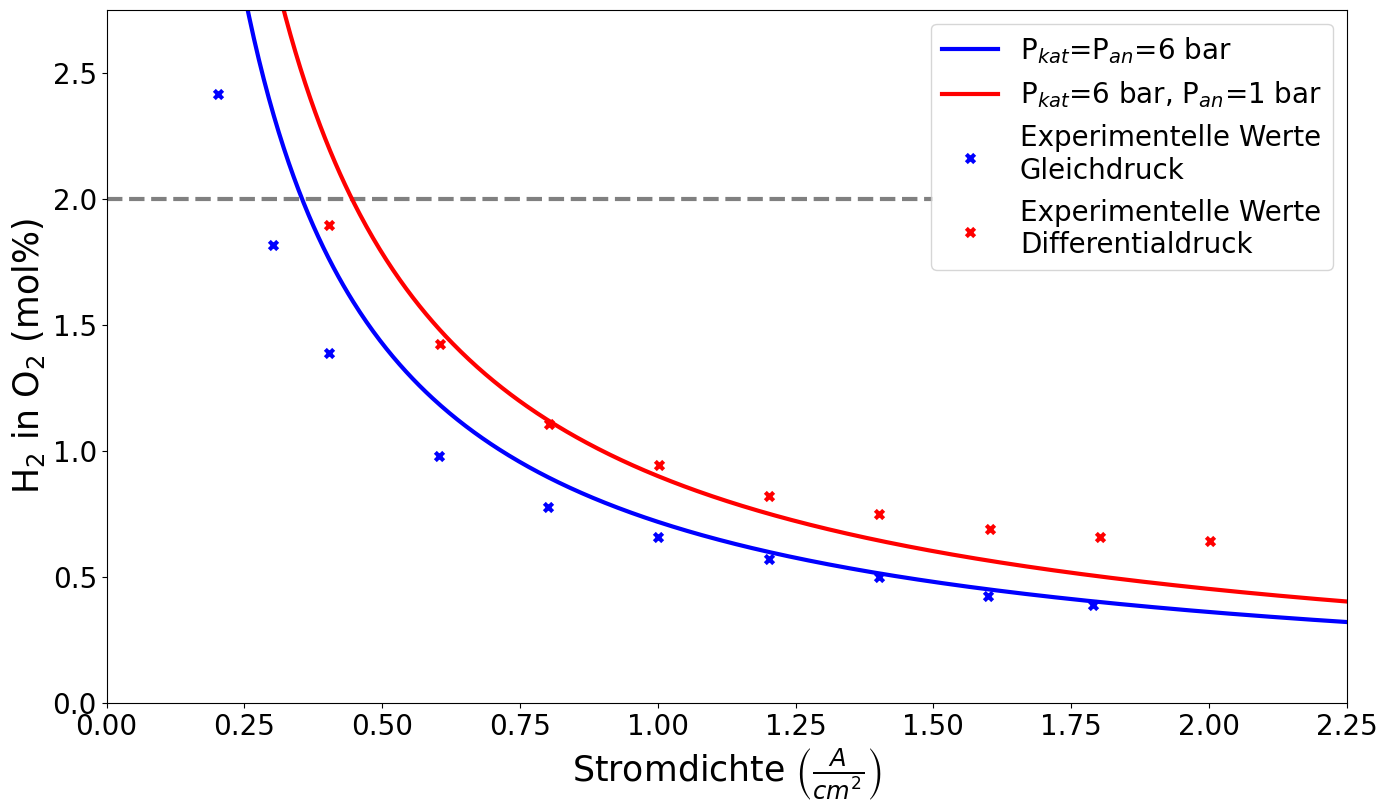

In [3]:
#constants
m_H=2*1.66*10**-27  #mass of H2 in kg
m_O=32*1.66*10**-27  #mass of O2 in kg
m_H2O=18*1.66*10**-27  #mass of H2O in kg
M_H2O=18*10**-3  #molar mass of water in kg/mol
density_H2O=980  #density of water in kg/m³; changes with temperature, therefore this value as a compromise
EW=1.1  #equivalent weight of Nafion in kg/mol

kbT=1.38*10**-23  #Boltzmann constant in J/K
R=8.314  #gas constant in J/mol/K
N_A=6.022*10**23  #Avogadro constant in 1/mol
F=9.648*10**4  #Faraday constant in As/mol

def gas_trans(P_cat, P_an, h_memb, T):
    P_cat_H2=[P_cat]
    P_an_O2=[P_an]
    # i=0
    # while i<10:
    #     #hydrogen and oxygen pressure at cathode and anode respectively
    #     P_cat_H2.append(P_cat+24*(4.65e-14*P_cat_H2[i]+2e-14*(P_cat_H2[i]-P_an_O2[i]))*curden/(4.65e-14*P_cat_H2[i]))
    #     P_an_O2.append(P_an+28*curden)
    #     i+=1
        
    #formation rates
    f_H2=curden/(2*F)  #hydrogen formation rate in mol/m²*s
    f_O2=curden/(4*F)  #oxygen formation rate in mol/m²*s
    
    #water speed through the membrane
    v_H2O=(-0.332*np.log10(curden)+5.59)*M_H2O*curden/(2*F*density_H2O)  #velocity of water in m/s; depending on current density
    v_H2O=v_H2O*h_memb/(178e-6)
    
    #diffusion (dif_coeff from 10.1016/j.ijhydene.2011.05.127)
    dif_coeff_H2=2.51e-05*np.exp(-16.51e3/(R*T))  #diffusion coefficient in m²/s
    dif_coeff_O2=1.90e-05*np.exp(-18.38e3/(R*T))
    sol_H2=0.72e-6  #solubility in mol/m³*Pa
    sol_O2=0.8e-6
    s_O2=sol_O2*P_an/1000  #solubility of O2 in Nafion in mol/l
    flux_dif_H2=dif_coeff_H2*sol_H2*P_cat_H2[-1]/h_memb  #diffusion flux in mol/m²*s
    flux_dif_O2=dif_coeff_O2*sol_O2*P_an_O2[-1]/h_memb
    #flux_dif_H2=4.65e-14*P_cat_H2[-1]/h_memb
    #flux_dif_O2=2e-14*P_an_O2[-1]/h_memb
        
    #drag
    drag_coeff=0.0134*T+0.03  #dimensionless drag coefficient
    c_H2O=40e3  #water concentration in Nafion in mol/m³
    flux_drag_H2=-0.13*np.log10(curden)*drag_coeff*P_cat_H2[-1]*sol_H2/(F*c_H2O)  #drag flux in mol/m²*s
    flux_drag_O2=0.13*np.log10(curden)*drag_coeff*P_an_O2[-1]*sol_O2/(F*c_H2O)
        
    #differential pressure
    flux_dp_H2=2e-14*(P_cat_H2[-1]-P_an_O2[-1])/h_memb  #dp flux in mol/m²*s
    flux_dp_O2=2e-14*(P_an_O2[-1]-P_cat_H2[-1])/h_memb
            
    #total flux
    flux_H2=flux_dif_H2+flux_dp_H2+flux_drag_H2  #total hydrogen flux in mol/m²*s
    flux_O2=flux_dif_O2+flux_dp_O2+flux_drag_O2  #total oxygen flux in mol/m²*s
    if type(curden)==np.ndarray or type(T)==np.ndarray:
        j=0
        while j<len(curden):
            if flux_O2[j]>f_O2[j]:
                flux_O2[j]=f_O2[j]
            if flux_O2[j]<0:
                flux_O2[j]=0
            j+=1
    else:
        if flux_O2>f_O2:
            flux_O2=f_O2
        if flux_O2<0:
            flux_O2=0
        
    #ratios
    H2_in_O2=100*flux_H2/(flux_H2+f_O2)
    O2_in_H2=100*flux_O2/(flux_O2+f_H2)
    alpha=f_H2/(flux_O2+f_H2)
    
    #calculation of H2 and O2 source terms and concentrations
    r_H2=f_H2/(h_cat*1000)  #H2 rate in mol/l/s 
    r_O2=flux_O2/(h_memb*1000)  #O2 rate in mol/l/s
    
    c_H2=sol_H2*P_cat/1000  #H2 concentration in mol/l; set to the solubility because of massive H2 abundance
    c_O2=flux_O2/(v_H2O*1000)  #O2 concentration in mol/l
    if type(curden)==np.ndarray or type(T)==np.ndarray:
        j=0
        while j<len(curden):
            if c_O2[j]>s_O2:
                c_O2[j]=s_O2
            if c_O2[j]<0:
                c_O2[j]=0
            j+=1
    else:
        if c_O2>s_O2:
            c_O2=s_O2
        if c_O2<0:
            c_O2=0
    return [O2_in_H2, H2_in_O2, f_O2, flux_O2, alpha]

curden=np.linspace(0,30000,1000)  #current density in A/m²
curden[0]=curden[1]
T=273.15+60
h_memb=183e-6
h_cat=10e-6


plt.rc("font", size=20)
plt.figure(figsize=(16,9))
plt.plot(curden/1e4, gas_trans(30e5,1e5,183e-6,273.15+40)[4])
plt.show()

plt.figure(figsize=(16,9))
plt.plot(curden/1e4, gas_trans(30e5,30e5,180e-6, 273.15+40)[0], color="blue", linewidth=3, label="40 °C, 30 bar, 180 µm")
plt.plot(curden/1e4, gas_trans(30e5,30e5,180e-6, 273.15+60)[0], color="orange", linewidth=3, label="60 °C, 30 bar, 180 µm")
plt.plot(curden/1e4, gas_trans(30e5,30e5,180e-6, 273.15+80)[0], color="red", linewidth=3, label="80 °C, 30 bar, 180 µm")
plt.plot(curden/1e4, gas_trans(1e5,1e5,180e-6, 273.15+60)[0], color="grey", linestyle="dashed", linewidth=3, label="60 °C, 1 bar, 180 µm")
plt.plot(curden/1e4, gas_trans(15e5,15e5,180e-6, 273.15+60)[0], color="grey", linestyle="dotted", linewidth=3, label="60 °C, 15 bar, 180 µm")
plt.plot(curden/1e4, gas_trans(30e5,30e5,100e-6, 273.15+60)[0], color="black", linestyle="dashed", linewidth=3, label="60 °C, 30 bar, 100 µm")
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
plt.ylabel(r"O$_2$ in H$_2$ (mol%)", fontsize=25)
plt.legend(loc="upper right")
plt.xlim(-.1,3)
plt.ylim(0,2)
plt.show()


fig, ax1=plt.subplots(figsize=(16,9))
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 183e-6, 273.15+40)[0], color="mediumpurple", linewidth=3, label="183 µm, 40 °C")
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 183e-6, 273.15+60)[0], color="blueviolet", linewidth=3, label="183 µm, 60 °C")
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 183e-6, 273.15+80)[0], color="indigo", linewidth=3, label="183 µm, 80 °C")
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 50.8e-6, 273.15+40)[0], color="mediumpurple", linestyle="dashed", linewidth=3, label="50,5 µm, 40 °C")
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 50.8e-6, 273.15+60)[0], color="blueviolet", linestyle="dashed", linewidth=3, label="50,5 µm, 60 °C")
ax1.plot(curden/1e4, gas_trans(30e5, 30e5, 50.8e-6, 273.15+80)[0], color="indigo", linestyle="dashed", linewidth=3, label="50,5 µm, 80 °C")
ax1.legend(bbox_to_anchor=(.23, 1), loc="upper left")
ax1.set_xticks(ticks=[0,0.5,1,1.5,2,2.5,3])
ax1.set_xlim(0,6)
ax1.set_ylim(0,4)
ax1.tick_params(axis='x', colors='blueviolet')
ax1.tick_params(axis='y', colors='blueviolet')
ax1.set_xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25, loc="left", color="blueviolet")
ax1.set_ylabel(r"O$_2$ in H$_2$ (mol%)", fontsize=25, color="blueviolet")
ax2=ax1.twinx()
ax3=ax1.twiny()
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 183e-6, 273.15+40)[0], color="limegreen", linewidth=3, label="183 µm, 40 °C")
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 183e-6, 273.15+60)[0], color="forestgreen", linewidth=3, label="183 µm, 60 °C")
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 183e-6, 273.15+80)[0], color="darkgreen", linewidth=3, label="183 µm, 80 °C")
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 50.8e-6, 273.15+40)[0], color="limegreen", linestyle="dashed", linewidth=3, label="50,5 µm, 40 °C")
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 50.8e-6, 273.15+60)[0], color="forestgreen", linestyle="dashed", linewidth=3, label="50,5 µm, 60 °C")
ax2.plot(curden/1e4+3, gas_trans(30e5, 20e5, 50.8e-6, 273.15+80)[0], color="darkgreen", linestyle="dashed", linewidth=3, label="50,5 µm, 80 °C")
ax2.legend(bbox_to_anchor=(1, 1))
ax3.set_xticks(ticks=[0,0.5,1,1.5,2,2.5,3])
ax3.set_xlim(-3,3)
ax2.set_ylim(0,4)
ax3.tick_params(axis='x', colors='forestgreen')
ax2.tick_params(axis='y', colors='forestgreen')
ax3.set_xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25, va="bottom", loc="right", color="forestgreen")
ax2.set_ylabel(r"O$_2$ in H$_2$ (mol%)", fontsize=25, color="forestgreen")
plt.axvline(x=0, color="black", alpha=.7)
plt.show()

input_file=np.loadtxt("./Schalenbach_crossover.txt")  #[0:10] balanced x, [10:20] balanced y, [20:29] differential x, [29:38] differential y

plt.figure(figsize=(16,9))
plt.hlines(2,0,1.5,color="grey",lw=3,ls="dashed")
plt.plot(curden/1e4, gas_trans(6e5,6e5,209e-6,273.15+80)[1],color="blue",linewidth=3,label="P$_{kat}$=P$_{an}$=6 bar")
plt.plot(curden/1e4, gas_trans(6e5,1e5,209e-6,273.15+80)[1],color="red",linewidth=3,label="P$_{kat}$=6 bar, P$_{an}$=1 bar")
plt.scatter(input_file[0:10], input_file[10:20], color="blue", marker="x",lw=3,label="Experimentelle Werte\nGleichdruck")
plt.scatter(input_file[20:29], input_file[29:38], color="red", marker="x",lw=3,label="Experimentelle Werte\nDifferentialdruck")
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$",fontsize=25)
plt.ylabel(r"H$_2$ in O$_2$ (mol%)",fontsize=25)
plt.xlim(0,2.25)
plt.ylim(0,2.75)
plt.legend()
plt.show()

# plt.figure(figsize=(8,8))
# plt.plot(curden/1e4, gas_trans(30e5,30e5,50e-6, 273.15+60)[1], color="black", linewidth=3, label="50 µm")
# plt.plot(curden/1e4, gas_trans(30e5,30e5,100e-6, 273.15+60)[1], color="red", linewidth=3, label="100 µm")
# plt.plot(curden/1e4, gas_trans(30e5,30e5,150e-6, 273.15+60)[1], color="lime", linewidth=3, label="150 µm")
# plt.plot(curden/1e4, gas_trans(30e5,30e5,200e-6, 273.15+60)[1], color="blue", linewidth=3, label="200 µm")
# plt.plot(curden/1e4, gas_trans(30e5,30e5,250e-6, 273.15+60)[1], color="cyan", linewidth=3, label="250 µm")
# plt.plot(curden/1e4, gas_trans(30e5,30e5,300e-6, 273.15+60)[1], color="magenta", linewidth=3, label="300 µm")
# plt.axhline(y=2, color="black", linestyle="dashed")
# plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
# plt.ylabel(r"H$_2$ in O$_2$ (%)", fontsize=25)
# plt.legend(loc="upper right")
# plt.xlim(0,2)
# plt.ylim(0,25)
# plt.show()


# plt.figure(figsize=(8,8))
# plt.plot(curden/1e4, gas_trans(30e5,1e5,50e-6, 273.15+60)[1], color="black", linewidth=3, label="50 µm")
# plt.plot(curden/1e4, gas_trans(30e5,1e5,100e-6, 273.15+60)[1], color="red", linewidth=3, label="100 µm")
# plt.plot(curden/1e4, gas_trans(30e5,1e5,150e-6, 273.15+60)[1], color="lime", linewidth=3, label="150 µm")
# plt.plot(curden/1e4, gas_trans(30e5,1e5,200e-6, 273.15+60)[1], color="blue", linewidth=3, label="200 µm")
# plt.plot(curden/1e4, gas_trans(30e5,1e5,250e-6, 273.15+60)[1], color="cyan", linewidth=3, label="250 µm")
# plt.plot(curden/1e4, gas_trans(30e5,1e5,300e-6, 273.15+60)[1], color="magenta", linewidth=3, label="300 µm")
# plt.axhline(y=2, color="black", linestyle="dashed")
# plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
# plt.ylabel(r"H$_2$ in O$_2$ (%)", fontsize=25)
# #plt.legend(loc="upper right")
# plt.xlim(0,2)
# plt.ylim(0,25)
# plt.show()

# plt.figure(figsize=(16,9))
# plt.plot(curden/1e4, gas_trans(30e5,30e5,50e-6,273.15+80)[2])
# plt.plot(curden/1e4, gas_trans(30e5,30e5,50e-6,273.15+80)[3])
# plt.xlim(0,0.08)
# plt.ylim(0,0.01)
# plt.rc("font", size=10)